# Carregamento dos artefatos

In [1]:
import joblib
import sys
import os
sys.path.append(os.path.abspath("../src"))
from data_processing import load_and_prepare_data, split_train_validation, create_mappings
from evaluation import evaluate_recommender
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler



In [2]:
print("1. Carregando dados e modelos...")

model_filename = '../data/raw/best_als_model.joblib'
print(f"Carregando o modelo de {model_filename}...")
best_model_als = joblib.load(model_filename)
print("Modelo als carregado!")

model_filename = '../models/cosine_sim.joblib'
print(f"Carregando o modelo de {model_filename}...")
cosine_sim = joblib.load(model_filename)
print("Modelo cosine_sim carregado!")

PATH_DATA = '../data/processed/online_retail_clean.parquet'
df = load_and_prepare_data(PATH_DATA)
train_df, validation_df = split_train_validation(df)

# Valores de Alpha para testar (0.0 = Apenas Conteúdo, 1.0 = Apenas ALS)
ALPHAS_TO_TEST = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]

mappings = joblib.load('../models/als_mappings.joblib')
item_map_als = mappings['item_map']
user_map_als = mappings['user_map']
inverse_item_map_als = mappings['inverse_item_map']


1. Carregando dados e modelos...
Carregando o modelo de ../data/raw/best_als_model.joblib...
Modelo als carregado!
Carregando o modelo de ../models/cosine_sim.joblib...
Modelo cosine_sim carregado!


In [3]:
print("\n2. Verificando consistência de dimensões...")
model_item_dim = best_model_als.item_factors.shape[0]
model_user_dim = best_model_als.user_factors.shape[0]
    
# Dimensões do mapeamento atual (dados recarregados)
map_item_dim = len(item_map_als)
map_user_dim = len(user_map_als)

print(f"Dimensão de itens do modelo ALS: {model_item_dim}, Dimensão de itens do mapeamento: {map_item_dim}")
print(f"Dimensão de usuários do modelo ALS: {model_user_dim}, Dimensão de usuários do mapeamento: {map_user_dim}")

num_items_als = model_item_dim 
if map_item_dim != model_item_dim:
    print(f"   AVISO: Inconsistência de Itens detectada (Mapa: {map_item_dim} vs Modelo: {model_item_dim}).")
    print(f"   -> Ajustando cálculo para usar apenas os {model_item_dim} itens conhecidos pelo modelo.")

# Ajuste de Usuários: Filtrar usuários que estão fora do range do modelo (IndexError)
train_user_items = train_df.groupby('CustomerID')['StockCode'].apply(set).to_dict()
validation_user_items = validation_df.groupby('CustomerID')['StockCode'].apply(set).to_dict()

valid_users_for_eval = [
    u for u in validation_user_items.keys() 
    if u in train_user_items and 
    user_map_als.get(u) is not None and 
    user_map_als[u] < model_user_dim # Garante que o índice existe na matriz de fatores
]
print(f"   -> Usuários válidos para avaliação (Warm Start & In-Model): {len(valid_users_for_eval)}")




2. Verificando consistência de dimensões...
Dimensão de itens do modelo ALS: 3049, Dimensão de itens do mapeamento: 3049
Dimensão de usuários do modelo ALS: 2703, Dimensão de usuários do mapeamento: 2703
   -> Usuários válidos para avaliação (Warm Start & In-Model): 2703


In [4]:
print("\n3. Criando ponte de alinhamento de índices...")

# Recriar mapeamento de conteúdo (baseado em todo o DF, como foi treinado)
grouped_descs = df.groupby('StockCode')['Description'].first()
item_map_content = {code: i for i, code in enumerate(grouped_descs.index)}

# Vetor de tradução: translation_array[indice_als] = indice_conteudo
# Usamos o tamanho do mapa (map_item_dim) para cobrir todos os IDs possíveis
translation_array = np.full(map_item_dim, -1, dtype=int)
matches_count = 0

# Lista auxiliar para guardar um exemplo de sucesso para demonstração
exemplo_match = None

for stock_code, als_idx in item_map_als.items():
    content_idx = item_map_content.get(stock_code)
    if content_idx is not None:
        translation_array[als_idx] = content_idx
        matches_count += 1
        if exemplo_match is None: # Guarda o primeiro que encontrar
            exemplo_match = (stock_code, als_idx, content_idx)

print(f"   -> Alinhamento concluído: {matches_count} itens do ALS encontrados no Conteúdo.")

# --- DEMONSTRAÇÃO PRÁTICA (SANITY CHECK) ---
if exemplo_match:
    stock_code_ex, idx_als_ex, idx_content_ex = exemplo_match
    print(f"\n   🔍 [DEMONSTRAÇÃO PRÁTICA] Verificando Item: '{stock_code_ex}'")
    print(f"      1. No Dicionário ALS (item_map_als), ele é o índice: {idx_als_ex}")
    print(f"      2. No Dicionário Conteúdo (item_map_content), ele é o índice: {idx_content_ex}")
    print(f"      3. A Ponte (translation_array[{idx_als_ex}]) deve apontar para {idx_content_ex}...")
    
    valor_na_ponte = translation_array[idx_als_ex]
    if valor_na_ponte == idx_content_ex:
        print(f"      ✅ SUCESSO! A ponte retornou {valor_na_ponte}. O alinhamento está correto.")
    else:
        print(f"      🚨 ERRO! A ponte retornou {valor_na_ponte}. Algo está errado.")
else:
    print("\n   ⚠️ AVISO: Nenhum item em comum encontrado para demonstração.")


3. Criando ponte de alinhamento de índices...
   -> Alinhamento concluído: 3049 itens do ALS encontrados no Conteúdo.

   🔍 [DEMONSTRAÇÃO PRÁTICA] Verificando Item: '85123A'
      1. No Dicionário ALS (item_map_als), ele é o índice: 0
      2. No Dicionário Conteúdo (item_map_content), ele é o índice: 3233
      3. A Ponte (translation_array[0]) deve apontar para 3233...
      ✅ SUCESSO! A ponte retornou 3233. O alinhamento está correto.


# Calculando as matrizes de scores

In [5]:
print("\n4. Pré-calculando matrizes de scores...")

num_eval_users = len(valid_users_for_eval)

# Matrizes [Users x Items_Modelo]
matrix_als_raw = np.zeros((num_eval_users, num_items_als))
matrix_content_aligned = np.zeros((num_eval_users, num_items_als))

# Mapa auxiliar para saber qual linha da matriz pertence a qual usuário
eval_user_to_matrix_idx = {uid: i for i, uid in enumerate(valid_users_for_eval)}

for i, user_id in enumerate(valid_users_for_eval):
    if i % 100 == 0:
        print(f"   Processando usuário {i}/{num_eval_users}...", end='\r')
    
    # --- A. Scores ALS ---
    user_idx_als = user_map_als[user_id] # Seguro devido ao filtro anterior
    user_vec = best_model_als.user_factors[user_idx_als]
    # Produto escalar: (1, F) @ (F, I) = (1, I) -> Gera scores para os 3055 itens
    scores_als = user_vec @ best_model_als.item_factors.T
    matrix_als_raw[i] = scores_als

    # --- B. Scores Conteúdo (Alinhados) ---
    history_stockcodes = train_user_items.get(user_id, [])
    history_indices_content = []
    
    for sc in history_stockcodes:
        idx = item_map_content.get(sc)
        if idx is not None:
            history_indices_content.append(idx)
    
    if history_indices_content:
        # 1. Calcular similaridade no mundo do Conteúdo
        raw_content_scores = cosine_sim[history_indices_content].max(axis=0)
        
        # 2. Traduzir para o mundo do ALS
        # Truncamos o translation_array para o tamanho do modelo (ex: 3055)
        truncated_translation = translation_array[:num_items_als]
        
        # Máscara e preenchimento
        valid_mask = (truncated_translation != -1)
        valid_content_indices = truncated_translation[valid_mask]
        
        matrix_content_aligned[i, valid_mask] = raw_content_scores[valid_content_indices]

print(f"\n   -> Pré-cálculo finalizado.")


4. Pré-calculando matrizes de scores...
   Processando usuário 2700/2703...
   -> Pré-cálculo finalizado.


In [6]:
print("\n5. Iniciando Grid Search para encontrar o melhor Alpha...")
    
results_blend = []

# Função de recomendação dinâmica (Closure)
def rec_fn_hybrid_dynamic(user_id, k=10, alpha=0.5):
    # 1. Buscar dados pré-calculados
    matrix_idx = eval_user_to_matrix_idx.get(user_id)
    if matrix_idx is None: return []

    scores_als = matrix_als_raw[matrix_idx]
    scores_content = matrix_content_aligned[matrix_idx]

    # 2. Normalização MinMax do ALS (Por Usuário - Essencial para o Blend)
    min_als = scores_als.min()
    max_als = scores_als.max()

    if max_als - min_als == 0:
        scores_als_norm = np.zeros_like(scores_als)
    else:
        scores_als_norm = (scores_als - min_als) / (max_als - min_als)

    # 3. O Blend
    final_scores = (alpha * scores_als_norm) + ((1 - alpha) * scores_content)

    # # 4. Filtrar itens já comprados (Exclusão do Treino)
    # history_codes = train_user_items.get(user_id, [])
    # for code in history_codes:
    #     idx = item_map_als.get(code)
    #     # Só mascarar se o índice estiver dentro da dimensão do modelo
    #     if idx is not None and idx < len(final_scores):
    #         final_scores[idx] = -np.inf

    # 5. Top-K
    # argpartition é mais eficiente que argsort total
    top_k_indices = np.argpartition(final_scores, -k)[-k:]
    top_k_indices = top_k_indices[np.argsort(final_scores[top_k_indices])[::-1]]

    # 6. Converter para StockCodes
    return [inverse_item_map_als[i] for i in top_k_indices]


# Loop Principal
for alpha in ALPHAS_TO_TEST:
    print(f"\n   --- Testando Alpha = {alpha} ---")
    
    # Define a função para o alpha atual
    current_rec_fn = lambda uid, K=10, **kwargs: rec_fn_hybrid_dynamic(uid, k=K, alpha=alpha)
    
    # Avalia
    metrics = evaluate_recommender(
        valid_users_for_eval,
        current_rec_fn,
        validation_user_items,
        {},
        k=10
    )
    
    results_blend.append({
        'Alpha': alpha,
        'NDCG@10': metrics['NDCG@10'],
        'Precision@10': metrics['P@10'],
        'Recall@10': metrics['R@10']
    })
    print(f"      Result: NDCG@10 = {metrics['NDCG@10']:.4f}")

print("\n6. Resultados Finais do Grid Search:")
df_results = pd.DataFrame(results_blend)
print(df_results.sort_values(by='NDCG@10', ascending=False).reset_index(drop=True))


5. Iniciando Grid Search para encontrar o melhor Alpha...

   --- Testando Alpha = 0.0 ---
      Result: NDCG@10 = 0.1392

   --- Testando Alpha = 0.2 ---
      Result: NDCG@10 = 0.2324

   --- Testando Alpha = 0.4 ---
      Result: NDCG@10 = 0.2327

   --- Testando Alpha = 0.5 ---
      Result: NDCG@10 = 0.2328

   --- Testando Alpha = 0.6 ---
      Result: NDCG@10 = 0.2323

   --- Testando Alpha = 0.7 ---
      Result: NDCG@10 = 0.2319

   --- Testando Alpha = 0.8 ---
      Result: NDCG@10 = 0.2302

   --- Testando Alpha = 0.9 ---
      Result: NDCG@10 = 0.2263

   --- Testando Alpha = 0.95 ---
      Result: NDCG@10 = 0.2237

   --- Testando Alpha = 1.0 ---
      Result: NDCG@10 = 0.2213

6. Resultados Finais do Grid Search:
   Alpha   NDCG@10  Precision@10  Recall@10
0   0.50  0.232764      0.187162   0.159411
1   0.40  0.232748      0.187162   0.159316
2   0.20  0.232365      0.186718   0.158701
3   0.60  0.232348      0.186792   0.158518
4   0.70  0.231898      0.186607   0.15798

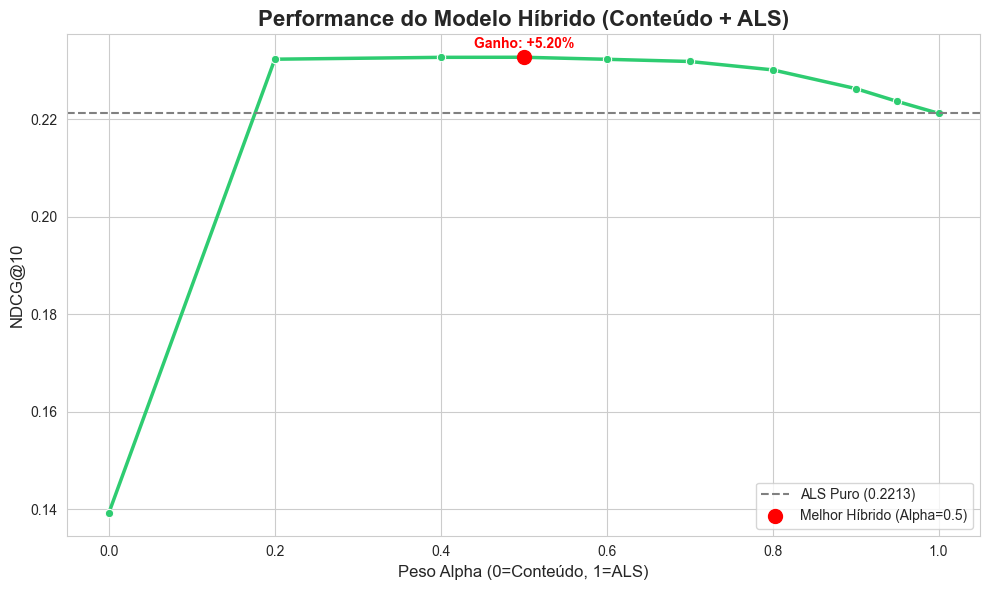

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seus resultados (copiados do output para garantir caso a variável tenha se perdido)
# Se a variável 'results_blend' ainda estiver na memória, o código usará ela.
if 'results_blend' not in locals():
    results_blend = [
        {'Alpha': 0.0, 'NDCG@10': 0.0292},
        {'Alpha': 0.2, 'NDCG@10': 0.0386},
        {'Alpha': 0.4, 'NDCG@10': 0.0524},
        {'Alpha': 0.5, 'NDCG@10': 0.0590},
        {'Alpha': 0.6, 'NDCG@10': 0.0628},
        {'Alpha': 0.7, 'NDCG@10': 0.0654},
        {'Alpha': 0.8, 'NDCG@10': 0.0661},
        {'Alpha': 0.9, 'NDCG@10': 0.0657},
        {'Alpha': 0.95, 'NDCG@10': 0.0655},
        {'Alpha': 1.0, 'NDCG@10': 0.0650}
    ]

df_results = pd.DataFrame(results_blend)

# Configuração do Gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Linha principal
sns.lineplot(data=df_results, x='Alpha', y='NDCG@10', marker='o', linewidth=2.5, color='#2ecc71')

# Destacar o ALS Puro (Baseline)
als_score = df_results[df_results['Alpha'] == 1.0]['NDCG@10'].values[0]
plt.axhline(y=als_score, color='gray', linestyle='--', label=f'ALS Puro ({als_score:.4f})')

# Destacar o Vencedor
best_row = df_results.loc[df_results['NDCG@10'].idxmax()]
plt.scatter(best_row['Alpha'], best_row['NDCG@10'], color='red', s=100, zorder=5, label=f'Melhor Híbrido (Alpha={best_row["Alpha"]})')

# Textos e Títulos
plt.title('Performance do Modelo Híbrido (Conteúdo + ALS)', fontsize=16, fontweight='bold')
plt.xlabel('Peso Alpha (0=Conteúdo, 1=ALS)', fontsize=12)
plt.ylabel('NDCG@10', fontsize=12)
plt.legend()

# Anotação do Ganho
gain = ((best_row['NDCG@10'] - als_score) / als_score) * 100
plt.annotate(f"Ganho: +{gain:.2f}%", 
             (best_row['Alpha'], best_row['NDCG@10']), 
             xytext=(best_row['Alpha'], best_row['NDCG@10'] + 0.002),
             ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()